# CELL1
# Loan Default Risk: Beating Lending Club's Pricing

A data science approach to credit risk on $7.5B+ of consumer loans across an 11-year window (2007–2018).

| | |
|---|---|
| **Author** | Talay Kamali |
| **Stack** | Python, Pandas, Scikit-learn, XGBoost, SHAP, Power BI |
| **Data** | LendingClub Accepted Loans, 2008 to 2018 (500K-loan random sample) |
| **Repo** | [github.com/talaykamali/loan-default-risk](#) |

---

## The question

From 2008 to 2018, Lending Club priced every loan using a letter-grade system from A to G that mapped directly to interest rate. The system works on average. Grade A loans default around 5%, Grade G above 30%. But within each grade, default rates vary a lot by purpose, geography, debt load, and credit history, and the grade alone never captures that.

So this project asks: could a model have priced these loans more accurately than the grade system did, and how much money would that have saved?

## Approach

The project runs in two parts.

> **Part 1 — Portfolio analysis.** Where does Lending Club bleed money? I break down default rates by grade, purpose, state, vintage year, and income to find the segments most underpriced by the grade system.

> **Part 2 — Predictive modeling.** Three classifiers (Logistic Regression, Random Forest, XGBoost) trained to predict default at origination. Judged not on AUC alone, but on dollars saved per loan when used as an approval threshold.

## Notebook index

| # | Notebook | Focus |
|---|----------|-------|
| 01 | `01_business_context.ipynb` | Framing and data overview |
| 02 | `02_portfolio_analysis.ipynb` | Default patterns across the portfolio |
| 03 | `03_feature_engineering.ipynb` | Leakage handling, feature design, splits |
| 04 | `04_modeling.ipynb` | LogReg, Random Forest, XGBoost, SHAP |
| 05 | `05_business_impact.ipynb` | Profit simulation and the dollar number |

## Headline results

> _Filled in after notebook 05. Placeholder for the LinkedIn hook._
> - **X%** reduction in charge-off losses vs. Lending Club's actual approvals
> - **$Y** saved per approved loan  
> - Top risk drivers surfaced via SHAP: `dti`, `int_rate`, `fico_range_low`

# CELL2
## 1. Environment and data load

The full accepted-loans file has 2.26M rows. I'm working with a random 500K-loan sample drawn uniformly across the file. The file is ordered chronologically, so a non-random slice (like reading the first N rows) collapses to a narrow time window and breaks the vintage analysis.

**Why a random sample, not the full file:**

| Concern | Mitigation |
|---|---|
| Class balance | Default rate is stable across vintages, so a random sample preserves it |
| Coverage | 500K rows still spans every grade, state, purpose, and vintage year |
| Speed | Each model iteration runs in seconds rather than minutes |

The same pipeline scales cleanly to the full 2.26M rows when needed.

In [1]:
# CELL3
# 
# # ─────────────────────────────────────────────────────────────────────────────
#  Imports and display configuration
# ─────────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Make sure the outputs folder exists before saving any figures
os.makedirs('outputs', exist_ok=True)

# Visual identity used across every notebook in this project
PALETTE = {
    'bg':      '#0f1117',
    'panel':   '#1a1d29',
    'text':    '#e8eaed',
    'muted':   '#8b8fa3',
    'primary': '#4c9aff',   # blue, neutral
    'success': '#36b37e',   # green, paid loans
    'danger':  '#ff5630',   # red, defaulted loans
    'warn':    '#ffab00',   # amber, in-flight loans
    'accent':  '#8777d9',   # purple, model output
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'savefig.facecolor': PALETTE['bg'],
    'axes.edgecolor':    PALETTE['muted'],
    'axes.labelcolor':   PALETTE['text'],
    'text.color':        PALETTE['text'],
    'xtick.color':       PALETTE['muted'],
    'ytick.color':       PALETTE['muted'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     18,
    'figure.figsize':    (12, 6),
    'figure.dpi':        110,
})

In [2]:
#CELL4
# # ─────────────────────────────────────────────────────────────────────────────
#  Load the accepted-loans file as a stratified random sample
#
#  The file is ordered chronologically, so taking the first N rows gives a
#  narrow time slice. We sample uniformly across the full file instead.
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_SIZE = 500_000
SEED        = 42

# Count total rows once (fast — just reads one column)
total_rows = sum(1 for _ in open('accepted_2007_to_2018Q4.csv')) - 1
print(f"Full file rows : {total_rows:,}")

# Pick which rows to skip so we keep ~SAMPLE_SIZE evenly spread rows
rng = np.random.default_rng(SEED)
keep_idx = set(rng.choice(total_rows, size=SAMPLE_SIZE, replace=False))
skip_rows = [i + 1 for i in range(total_rows) if i not in keep_idx]  # +1 for header

df = pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    low_memory=False,
    skiprows=skip_rows,
)

print(f"\nRows         : {df.shape[0]:>12,}")
print(f"Features     : {df.shape[1]:>12,}")
print(f"Memory       : {df.memory_usage(deep=True).sum() / 1e6:>10,.0f} MB")
print(f"Date range   : {df['issue_d'].min()}  to  {df['issue_d'].max()}")
print(f"Loan volume  : ${df['loan_amnt'].sum() / 1e9:>11,.2f} B")

Full file rows : 2,260,701

Rows         :      500,000
Features     :          151
Memory       :        728 MB
Date range   : Apr-2008  to  Sep-2018
Loan volume  : $       7.53 B


# CELL5
## 2. Loan status landscape

Every loan in the dataset carries one of seven status labels. The distribution is the first read on portfolio health: what's been paid back, what's still active, and what's already been written off as a loss.

| Status | Meaning |
|---|---|
| `Fully Paid` | Loan closed successfully |
| `Charged Off` | Written off as a loss after extended delinquency |
| `Current` | On schedule, still active |
| `Late (16-30 days)` / `Late (31-120 days)` | Behind on payments |
| `In Grace Period` | Within 15 days of missed payment |
| `Default` | In default but not yet charged off |

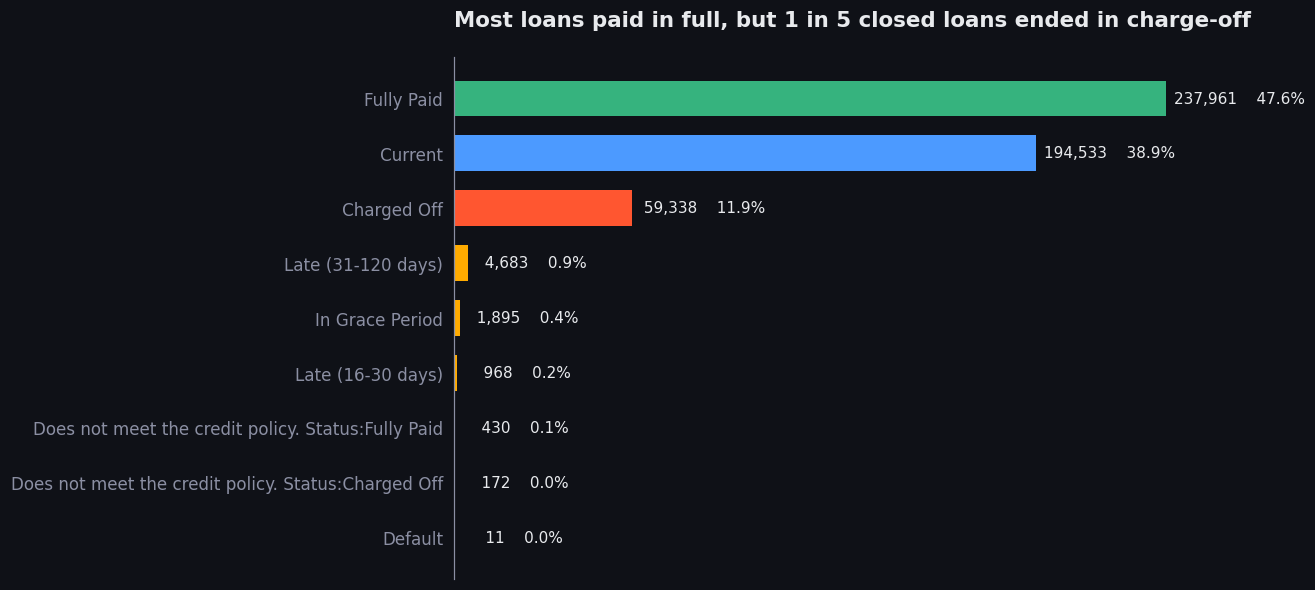

In [3]:
# CELL6
# # ─────────────────────────────────────────────────────────────────────────────
#  Distribution of loan statuses
# ─────────────────────────────────────────────────────────────────────────────
status = (
    df['loan_status']
      .value_counts()
      .rename_axis('status')
      .reset_index(name='count')
)
status['share'] = status['count'] / status['count'].sum()

# Color logic: green = paid, red = default-adjacent, blue = active, amber = late
def status_color(s):
    if s == 'Fully Paid':                    return PALETTE['success']
    if s in ('Charged Off', 'Default'):      return PALETTE['danger']
    if s == 'Current':                       return PALETTE['primary']
    return PALETTE['warn']

status['color'] = status['status'].map(status_color)

fig, ax = plt.subplots(figsize=(12, 5.5))

bars = ax.barh(
    status['status'],
    status['count'],
    color=status['color'],
    height=0.65,
    edgecolor='none',
)
ax.invert_yaxis()

# Value labels at the end of each bar
for bar, (cnt, shr) in zip(bars, zip(status['count'], status['share'])):
    ax.text(
        bar.get_width() + status['count'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{cnt:>7,}    {shr:.1%}',
        va='center', ha='left',
        color=PALETTE['text'], fontsize=10,
    )

ax.set_xlim(0, status['count'].max() * 1.18)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(
    'Most loans paid in full, but 1 in 5 closed loans ended in charge-off',
    loc='left', color=PALETTE['text'], pad=20,
)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color(PALETTE['muted'])
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('outputs/01_loan_status_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# CELL7

## 3. Defining the target

Five of the seven statuses are ambiguous. Loans marked `Current`, `Late`, `In Grace Period`, or `Default` haven't reached a final outcome yet, so we don't know if they'll end up paid or written off.

For the model in notebook 04, I restrict the data to the two terminal states:

| Status | Treatment | Reasoning |
|---|---|---|
| `Fully Paid` | `default = 0` | Loan closed, no loss |
| `Charged Off` | `default = 1` | Loan written off |
| Everything else | Excluded from model | Outcome unknown |

> The portfolio analysis in notebook 02 keeps every status. Active and late loans are useful for understanding the live book, even if they're not modelable.

In [4]:
#CELL8
# 
# # ─────────────────────────────────────────────────────────────────────────────
#  Headline numbers: the story this project tells
# ─────────────────────────────────────────────────────────────────────────────
terminal = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
terminal['default'] = (terminal['loan_status'] == 'Charged Off').astype(int)

n_loans      = len(terminal)
n_defaults   = terminal['default'].sum()
default_rate = terminal['default'].mean()

# Principal that was never recovered on charged-off loans
charged_off_loss = (
    terminal.loc[terminal['default'] == 1, 'loan_amnt'].sum()
    - terminal.loc[terminal['default'] == 1, 'total_rec_prncp'].sum()
)

print('=' * 58)
print(f'  TERMINAL LOANS              {n_loans:>14,}')
print(f'  CHARGED OFF                 {n_defaults:>14,}    ({default_rate:.1%})')
print(f'  TOTAL PRINCIPAL LOST        ${charged_off_loss / 1e6:>12,.1f}  M')
print(f'  AVG LOSS PER DEFAULT        ${charged_off_loss / n_defaults:>12,.0f}')
print('=' * 58)

  TERMINAL LOANS                     297,299
  CHARGED OFF                         59,338    (20.0%)
  TOTAL PRINCIPAL LOST        $       662.7  M
  AVG LOSS PER DEFAULT        $      11,168


# CELL9
## 4. What's next

| Notebook | What it does |
|---|---|
| `02_portfolio_analysis` | Digs into *patterns* behind the default rate: grades, purposes, states, vintages, and where the grade-based pricing system breaks down |
| `03_feature_engineering` | Cleans the dataset, handles leakage, engineers risk features, splits train/test |
| `04_modeling` | Trains and compares LogReg, Random Forest, XGBoost — with SHAP for explainability |
| `05_business_impact` | Translates predictions into dollars: the headline number |

Notebook 02 starts where this one ends, with the terminal loans we just isolated.